In [35]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/iamaniketdubey/heart-disease/heart_disease_raw.csv


In [36]:
df = pd.read_csv("/kaggle/input/datasets/iamaniketdubey/heart-disease/heart_disease_raw.csv")

In [37]:
df.shape

(10000, 23)

In [38]:
df.isnull().sum()

patient_id               0
age                      0
sex                      0
chest_pain_type          0
resting_bp               0
cholesterol            406
fasting_blood_sugar      0
resting_ecg              0
max_heart_rate           0
exercise_angina          0
st_depression          211
st_slope                 0
num_vessels              0
thalassemia              0
bmi                    183
smoking_status           0
diabetes                 0
family_history           0
physical_activity        0
alcohol_consumption      0
stress_level           274
sleep_hours            294
target                   0
dtype: int64

In [39]:
# =============================================================================
# STEP 2 — EXPLORATORY DATA ANALYSIS (EDA)
# Project : Heart Disease Risk Prediction
# Author  : Aniket Dubey
# =============================================================================
# What this file covers:
#   1. Shape & data types
#   2. Missing value analysis
#   3. Target distribution
#   4. Numeric feature distributions (histograms + boxplots)
#   5. Categorical feature risk rates
#   6. Correlation heatmap
#   7. Feature-vs-target correlation bar chart
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ── Config ────────────────────────────────────────────────────────────────────
DATA_PATH = "/kaggle/input/datasets/iamaniketdubey/heart-disease/heart_disease_raw.csv"   # update path if needed
PLOT_DIR  = "eda_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.0)

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)

# =============================================================================
# 1. SHAPE & DATA TYPES
# =============================================================================
print("=" * 55)
print("1. SHAPE & DATA TYPES")
print("=" * 55)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print()
print(df.dtypes.to_string())

# ── Why this matters ──────────────────────────────────────────────────────────
# - 'object' dtype = categorical → needs encoding before model training
# - 'float64' on integer-looking columns = missing values exist (pandas
#   auto-converts int → float when NaN is present)
# - 'patient_id' is an ID column → drop before modeling

# =============================================================================
# 2. MISSING VALUE ANALYSIS
# =============================================================================
print()
print("=" * 55)
print("2. MISSING VALUES")
print("=" * 55)

miss_count = df.isnull().sum()
miss_pct   = (miss_count / len(df) * 100).round(2)
miss_df    = pd.DataFrame({
    "Missing Count": miss_count,
    "Missing %"    : miss_pct
})
miss_df = miss_df[miss_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print(miss_df.to_string())

# ── Decision guide ────────────────────────────────────────────────────────────
# < 5%  → safe to impute (median for numeric, mode for categorical)
# 5–20% → impute carefully, consider a "was_missing" flag feature
# > 20% → consider dropping the column

# =============================================================================
# 3. TARGET DISTRIBUTION
# =============================================================================
print()
print("=" * 55)
print("3. TARGET DISTRIBUTION")
print("=" * 55)

vc = df["target"].value_counts().sort_index()
print(f"  No Disease (0) : {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)")
print(f"  Disease    (1) : {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)")

# ── Why this matters ──────────────────────────────────────────────────────────
# - Imbalanced target affects which metric to use:
#     Balanced  → Accuracy is fine
#     Imbalanced→ Use F1, Precision-Recall AUC, ROC-AUC
# - Our 60/40 split is mildly imbalanced → use class_weight='balanced'
#   in the model; no need for SMOTE at this ratio

# PLOT 1 — Target distribution
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ["No Disease (0)", "Disease (1)"],
    vc.values,
    color=["#2ecc71", "#e74c3c"],
    edgecolor="white", linewidth=1.5, width=0.5
)
for bar, val in zip(bars, vc.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 60,
        f"{val:,}\n({val/len(df)*100:.1f}%)",
        ha="center", fontsize=11, fontweight="bold"
    )
ax.set_title("Target Class Distribution", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
ax.set_ylim(0, 7500)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/01_target_distribution.png", dpi=150)
plt.close()
print(f"\n  ✓ Saved → {PLOT_DIR}/01_target_distribution.png")

# =============================================================================
# 4A. NUMERIC FEATURE DISTRIBUTIONS (Histograms)
# =============================================================================
print()
print("=" * 55)
print("4A. NUMERIC DISTRIBUTIONS")
print("=" * 55)

num_cols = ["age", "resting_bp", "cholesterol", "max_heart_rate",
            "st_depression", "bmi"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color, name in [(0, "#2ecc71", "No Disease"), (1, "#e74c3c", "Disease")]:
        data = df[df["target"] == label][col].dropna()
        axes[i].hist(data, bins=30, alpha=0.55, color=color,
                     label=name, edgecolor="white")
    axes[i].set_title(col.replace("_", " ").title(), fontweight="bold")
    axes[i].legend(fontsize=8)
    axes[i].spines[["top", "right"]].set_visible(False)

fig.suptitle("Numeric Feature Distributions by Target", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/02_numeric_distributions.png", dpi=150)
plt.close()
print(f"  ✓ Saved → {PLOT_DIR}/02_numeric_distributions.png")

# ── What to look for ─────────────────────────────────────────────────────────
# - Clear separation between green/red = strong predictor
# - Heavy overlap = weak individual predictor (may still help in combination)
# - Skewed distributions = may need log transform before modeling

# =============================================================================
# 4B. BOXPLOTS — Outlier Detection
# =============================================================================
print()
print("=" * 55)
print("4B. BOXPLOTS — OUTLIER DETECTION")
print("=" * 55)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data0 = df[df["target"] == 0][col].dropna()
    data1 = df[df["target"] == 1][col].dropna()

    bp = axes[i].boxplot(
        [data0, data1],
        patch_artist=True,
        tick_labels=["No Disease", "Disease"],
        medianprops=dict(color="black", linewidth=2)
    )
    bp["boxes"][0].set_facecolor("#2ecc71"); bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_facecolor("#e74c3c"); bp["boxes"][1].set_alpha(0.7)
    axes[i].set_title(col.replace("_", " ").title(), fontweight="bold")
    axes[i].spines[["top", "right"]].set_visible(False)

    # Print IQR-based outlier count
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col:<20} outliers (IQR rule): {n_outliers}")

fig.suptitle("Outlier Detection — Numeric Features vs Target",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/03_boxplots_outliers.png", dpi=150)
plt.close()
print(f"\n  ✓ Saved → {PLOT_DIR}/03_boxplots_outliers.png")

# ── Outlier strategy ──────────────────────────────────────────────────────────
# Logistic Regression is NOT tree-based — it IS sensitive to extreme values.
# Strategy: cap (Winsorize) at 1st & 99th percentile in the cleaning step.

# =============================================================================
# 5. CATEGORICAL FEATURE RISK RATES
# =============================================================================
print()
print("=" * 55)
print("5. CATEGORICAL RISK RATES")
print("=" * 55)

cat_cols = ["chest_pain_type", "st_slope", "num_vessels",
            "thalassemia", "smoking_status", "physical_activity"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    risk = df.groupby(col)["target"].mean().reset_index()
    risk.columns = [col, "disease_rate"]

    axes[i].bar(
        risk[col].astype(str), risk["disease_rate"],
        color="#e74c3c", alpha=0.75, edgecolor="white"
    )
    axes[i].set_title(
        f"{col.replace('_',' ').title()}\n(Disease Rate per Category)",
        fontweight="bold", fontsize=10
    )
    axes[i].set_ylabel("Disease Rate")
    axes[i].set_ylim(0, 1.0)
    axes[i].axhline(df["target"].mean(), color="gray",
                    ls="--", lw=1, label=f"avg={df['target'].mean():.2f}")
    axes[i].legend(fontsize=8)
    axes[i].spines[["top", "right"]].set_visible(False)

    # Print the actual rates
    print(f"\n  {col}:")
    print(risk.to_string(index=False))

fig.suptitle("Disease Rate by Categorical Feature",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/04_categorical_risk.png", dpi=150)
plt.close()
print(f"\n  ✓ Saved → {PLOT_DIR}/04_categorical_risk.png")

# =============================================================================
# 6. CORRELATION HEATMAP (all numeric features)
# =============================================================================
print()
print("=" * 55)
print("6. CORRELATION HEATMAP")
print("=" * 55)

num_df = df.select_dtypes(include="number").drop(columns=["patient_id"], errors="ignore")

fig, ax = plt.subplots(figsize=(13, 10))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn_r", center=0, linewidths=0.4, ax=ax,
    annot_kws={"size": 8}, cbar_kws={"shrink": 0.8}
)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/05_correlation_heatmap.png", dpi=150)
plt.close()
print(f"  ✓ Saved → {PLOT_DIR}/05_correlation_heatmap.png")

# ── What to look for ─────────────────────────────────────────────────────────
# - High correlation between two FEATURES (|r| > 0.8) = multicollinearity
#   → consider dropping one (Logistic Regression is affected by this)
# - High correlation with TARGET = strong predictor

# =============================================================================
# 7. FEATURE CORRELATION WITH TARGET (ranked bar)
# =============================================================================
print()
print("=" * 55)
print("7. FEATURE-TARGET CORRELATIONS (ranked)")
print("=" * 55)

target_corr = num_df.corr()["target"].drop("target").sort_values()
print(target_corr.round(3).to_string())

colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in target_corr.values]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Feature Correlation with Target (Heart Disease)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Pearson Correlation")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/06_target_correlation.png", dpi=150)
plt.close()
print(f"\n  ✓ Saved → {PLOT_DIR}/06_target_correlation.png")

# =============================================================================
# SUMMARY — Key EDA Findings
# =============================================================================
print()
print("=" * 55)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 55)
print("""
MISSING VALUES:
  cholesterol    4.06%  → impute with median
  sleep_hours    2.94%  → impute with median
  stress_level   2.74%  → impute with median
  st_depression  2.11%  → impute with median
  bmi            1.83%  → impute with median

OUTLIERS TO CAP (Winsorize at 1st–99th percentile):
  cholesterol    → values up to 468
  resting_bp     → values up to 198
  st_depression  → right-skewed, values up to 6.5

TOP PREDICTORS (from correlation with target):
  Positive: num_vessels, exercise_angina, thalassemia,
            st_depression, age, family_history
  Negative: max_heart_rate, physical_activity (high),
            sleep_hours

CLASS IMBALANCE:
  60% disease / 40% no disease
  → use class_weight='balanced' in Logistic Regression
  → evaluate with F1 + ROC-AUC, not just accuracy

NEXT STEP → Data Cleaning & Preprocessing
""")

1. SHAPE & DATA TYPES
Rows    : 10,000
Columns : 23

patient_id              object
age                      int64
sex                      int64
chest_pain_type          int64
resting_bp               int64
cholesterol            float64
fasting_blood_sugar      int64
resting_ecg              int64
max_heart_rate           int64
exercise_angina          int64
st_depression          float64
st_slope                 int64
num_vessels              int64
thalassemia              int64
bmi                    float64
smoking_status          object
diabetes                 int64
family_history           int64
physical_activity       object
alcohol_consumption     object
stress_level           float64
sleep_hours            float64
target                   int64

2. MISSING VALUES
               Missing Count  Missing %
cholesterol              406       4.06
sleep_hours              294       2.94
stress_level             274       2.74
st_depression            211       2.11
bmi            

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)

df = pd.read_csv("/kaggle/input/datasets/iamaniketdubey/heart-disease/heart_disease_raw.csv")  # update path

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

Shape: (10000, 23)

Data Types:
 patient_id              object
age                      int64
sex                      int64
chest_pain_type          int64
resting_bp               int64
cholesterol            float64
fasting_blood_sugar      int64
resting_ecg              int64
max_heart_rate           int64
exercise_angina          int64
st_depression          float64
st_slope                 int64
num_vessels              int64
thalassemia              int64
bmi                    float64
smoking_status          object
diabetes                 int64
family_history           int64
physical_activity       object
alcohol_consumption     object
stress_level           float64
sleep_hours            float64
target                   int64
dtype: object


In [41]:
miss_count = df.isnull().sum()
miss_pct   = (miss_count / len(df) * 100).round(2)



miss_df = pd.DataFrame({
    "Missing Count": miss_count,
    "Missing %"    : miss_pct
})

# show only columns that actually have missing values
miss_df = miss_df[miss_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print(miss_df)

               Missing Count  Missing %
cholesterol              406       4.06
sleep_hours              294       2.94
stress_level             274       2.74
st_depression            211       2.11
bmi                      183       1.83


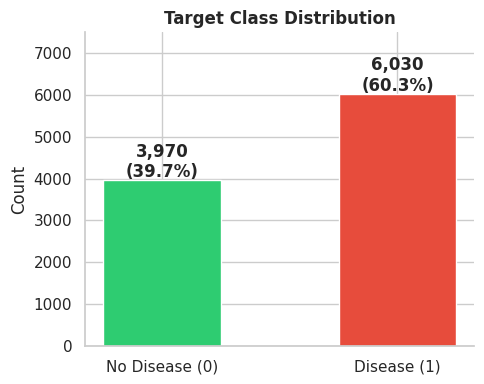

In [42]:
fig, ax = plt.subplots(figsize=(5, 4))

vc = df["target"].value_counts().sort_index()
bars = ax.bar(
    ["No Disease (0)", "Disease (1)"],
    vc.values,
    color=["#2ecc71", "#e74c3c"],
    edgecolor="white", width=0.5
)

for bar, val in zip(bars, vc.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 60,
        f"{val:,}\n({val/len(df)*100:.1f}%)",
        ha="center", fontweight="bold"
    )

ax.set_title("Target Class Distribution", fontweight="bold")
ax.set_ylabel("Count")
ax.set_ylim(0, 7500)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

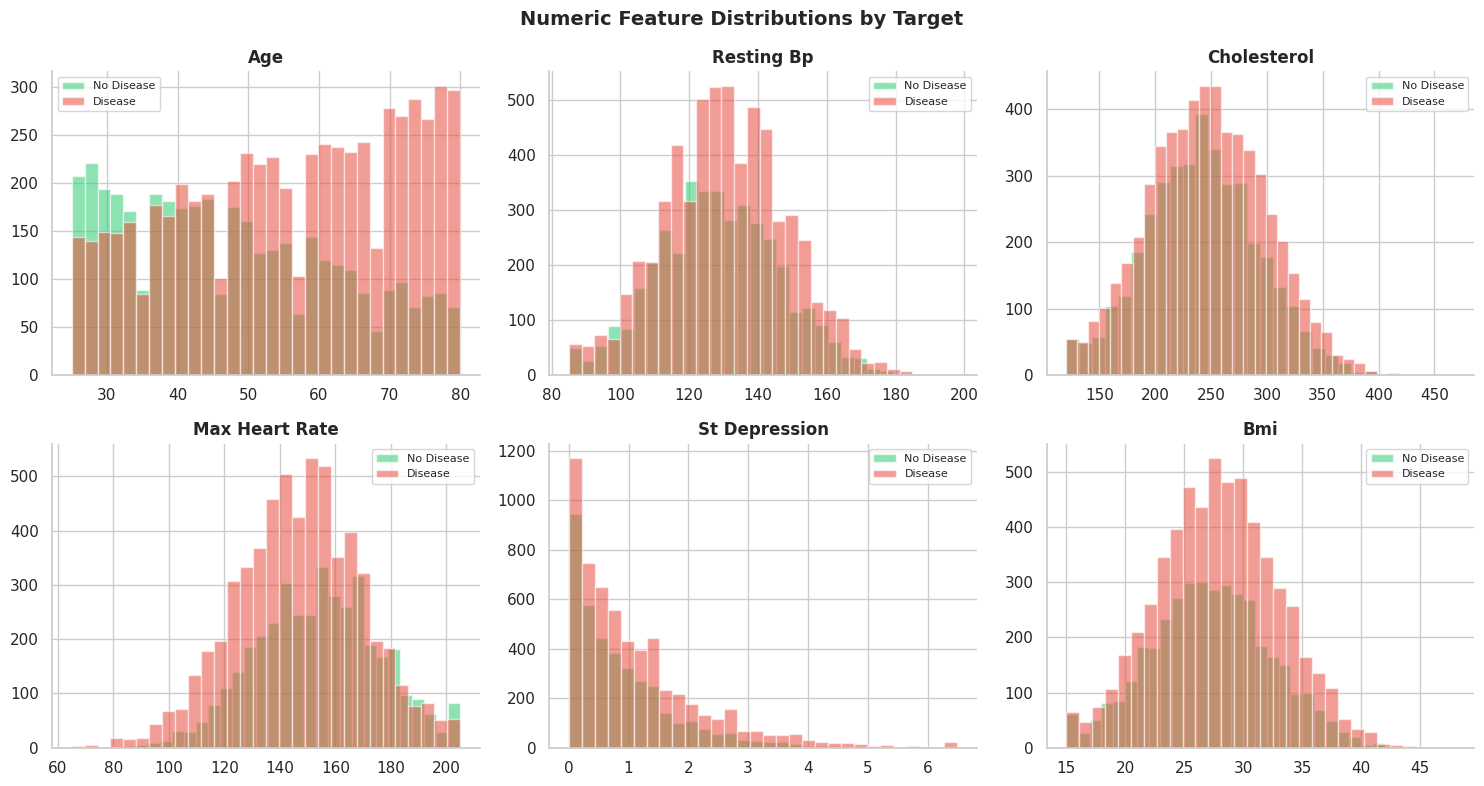

In [43]:
num_cols = ["age", "resting_bp", "cholesterol", 
            "max_heart_rate", "st_depression", "bmi"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color, name in [(0, "#2ecc71", "No Disease"), 
                                (1, "#e74c3c", "Disease")]:
        data = df[df["target"] == label][col].dropna()
        axes[i].hist(data, bins=30, alpha=0.55, 
                     color=color, label=name, edgecolor="white")
    
    axes[i].set_title(col.replace("_", " ").title(), fontweight="bold")
    axes[i].legend(fontsize=8)
    axes[i].spines[["top", "right"]].set_visible(False)

fig.suptitle("Numeric Feature Distributions by Target", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

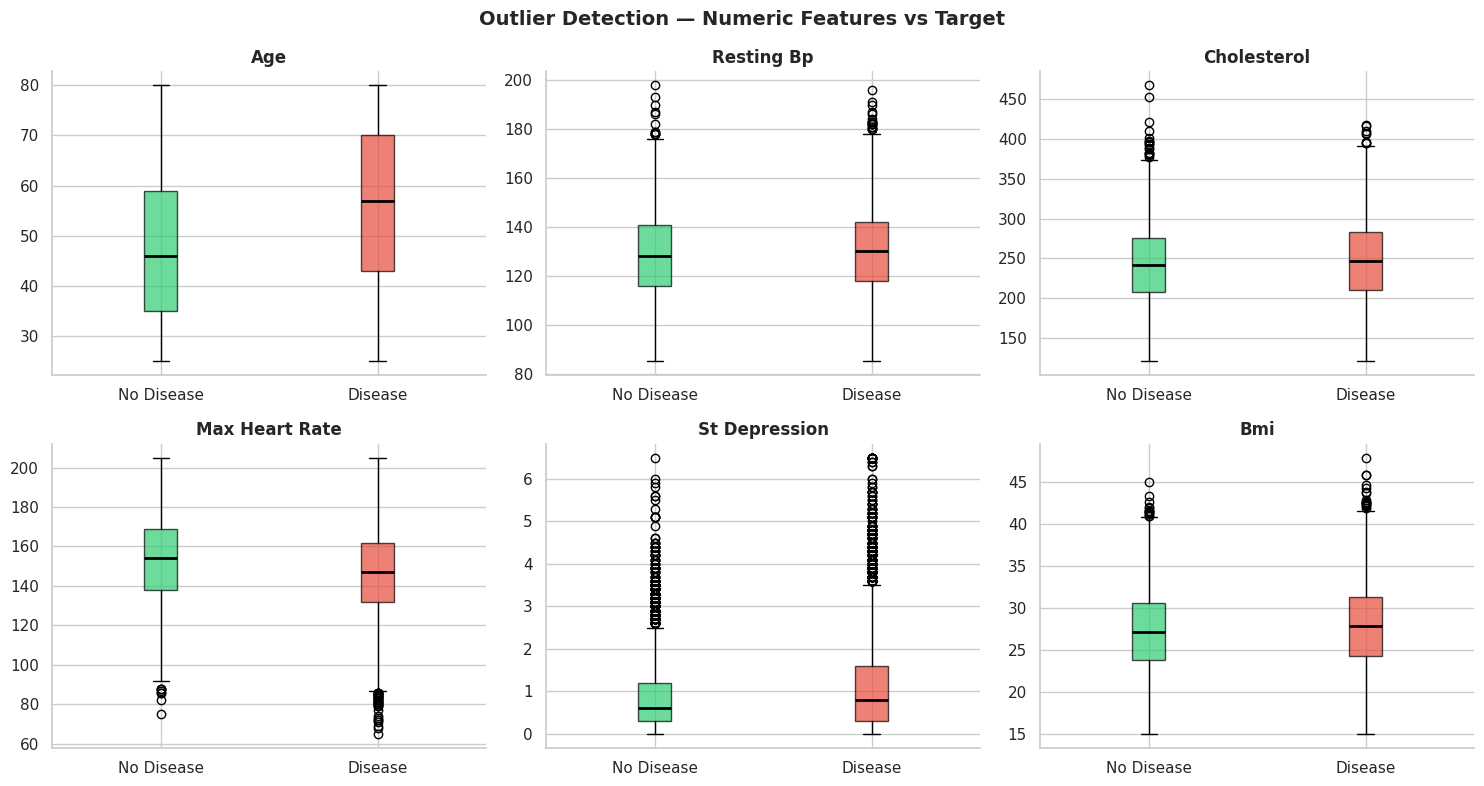

In [44]:
num_cols = ["age", "resting_bp", "cholesterol", 
            "max_heart_rate", "st_depression", "bmi"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data0 = df[df["target"] == 0][col].dropna()
    data1 = df[df["target"] == 1][col].dropna()

    bp = axes[i].boxplot(
        [data0, data1],
        patch_artist=True,
        tick_labels=["No Disease", "Disease"],
        medianprops=dict(color="black", linewidth=2)
    )
    bp["boxes"][0].set_facecolor("#2ecc71")
    bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_facecolor("#e74c3c")
    bp["boxes"][1].set_alpha(0.7)

    axes[i].set_title(col.replace("_", " ").title(), fontweight="bold")
    axes[i].spines[["top", "right"]].set_visible(False)

fig.suptitle("Outlier Detection — Numeric Features vs Target", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

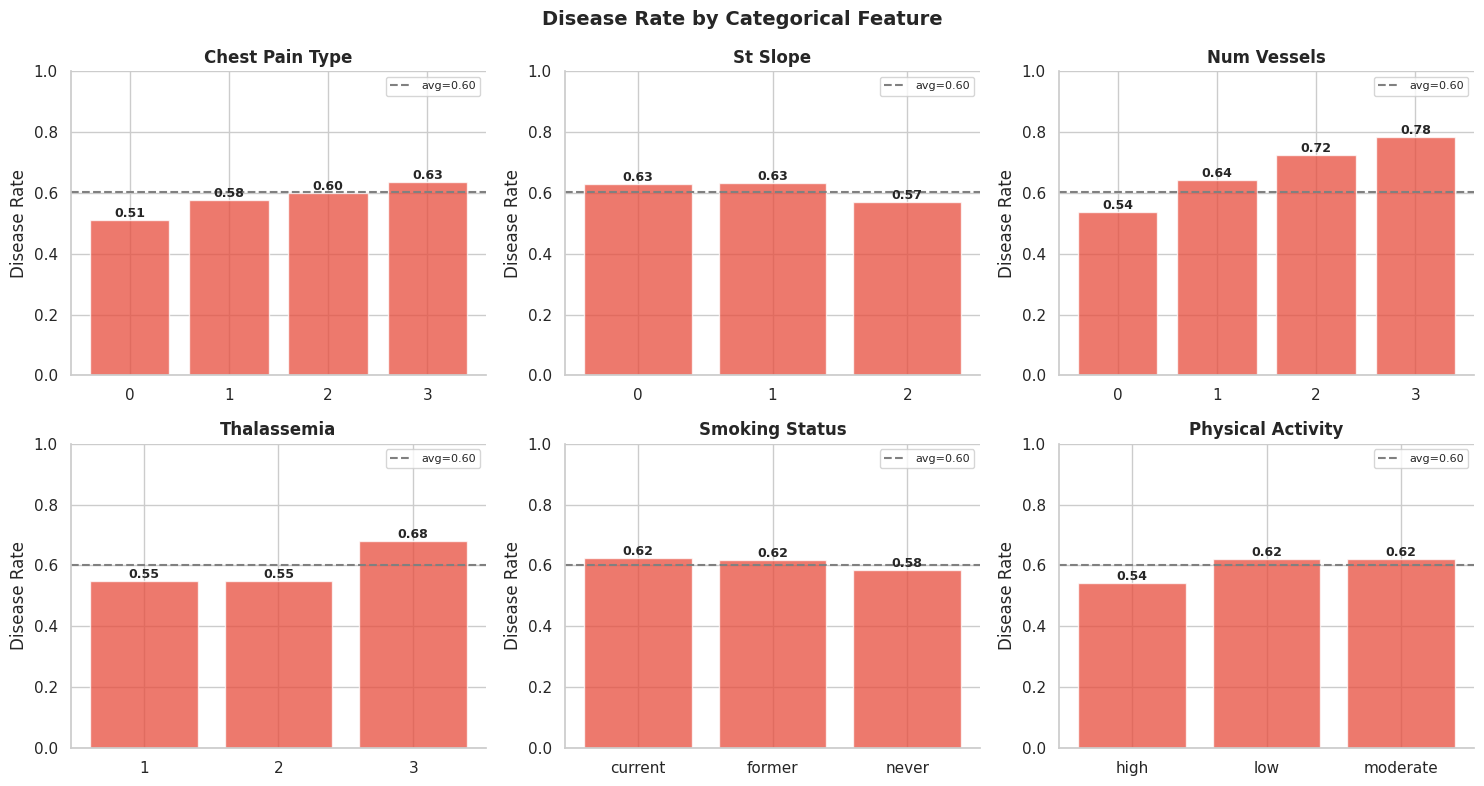

In [45]:
cat_cols = ["chest_pain_type", "st_slope", "num_vessels",
            "thalassemia", "smoking_status", "physical_activity"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

avg_rate = df["target"].mean()

for i, col in enumerate(cat_cols):
    risk = df.groupby(col)["target"].mean().reset_index()
    risk.columns = [col, "disease_rate"]

    bars = axes[i].bar(
        risk[col].astype(str), 
        risk["disease_rate"],
        color="#e74c3c", alpha=0.75, edgecolor="white"
    )
    
    # label each bar with its rate
    for bar, val in zip(bars, risk["disease_rate"]):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.2f}",
            ha="center", fontsize=9, fontweight="bold"
        )

    axes[i].axhline(avg_rate, color="gray", ls="--", 
                    lw=1.5, label=f"avg={avg_rate:.2f}")
    axes[i].set_title(col.replace("_", " ").title(), fontweight="bold")
    axes[i].set_ylabel("Disease Rate")
    axes[i].set_ylim(0, 1.0)
    axes[i].legend(fontsize=8)
    axes[i].spines[["top", "right"]].set_visible(False)

fig.suptitle("Disease Rate by Categorical Feature", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

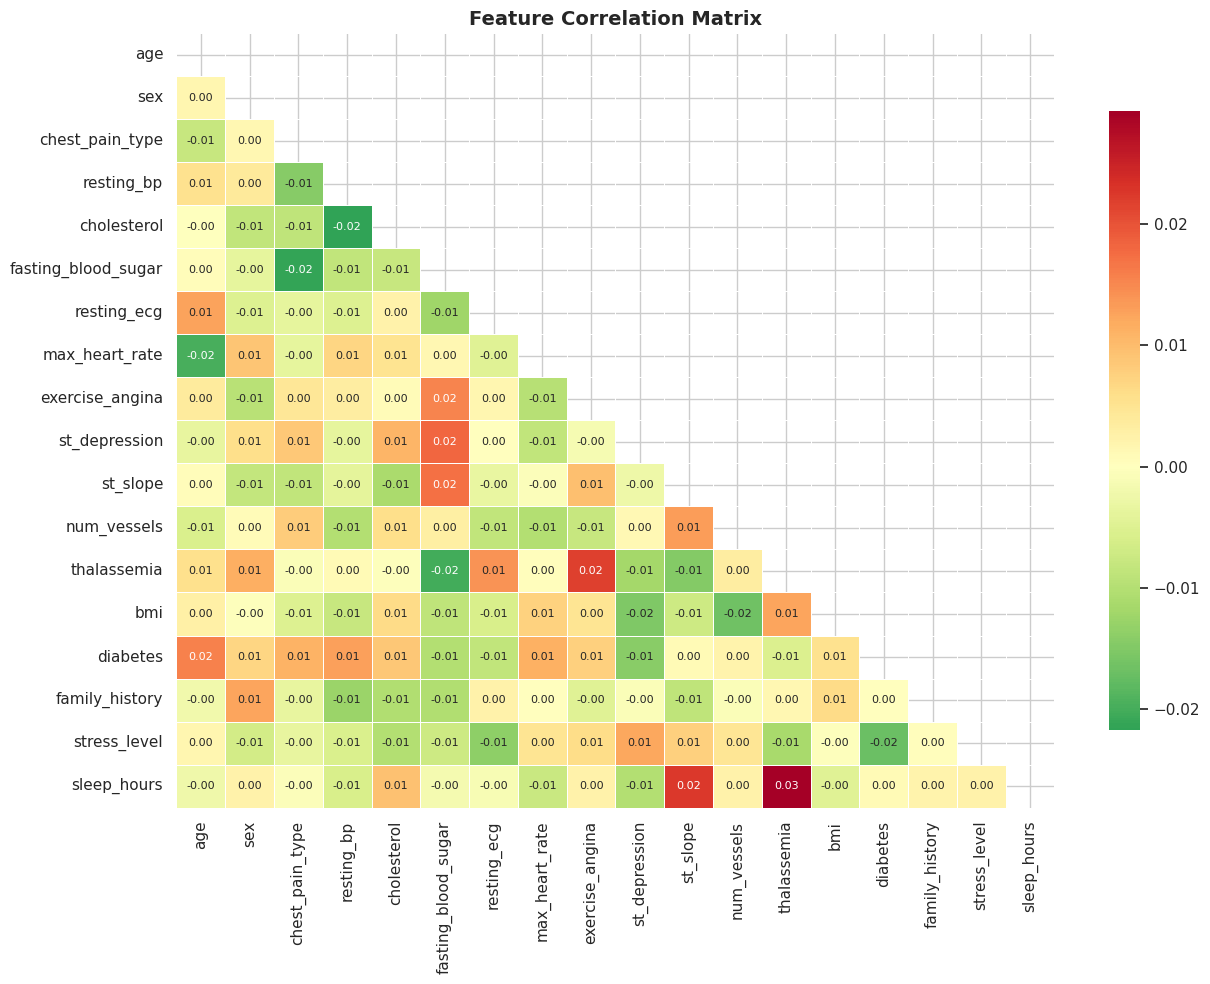

In [46]:
num_df = df.select_dtypes(include="number").drop(columns=["target"])

fig, ax = plt.subplots(figsize=(13, 10))

corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr, mask=mask,
    annot=True, fmt=".2f",
    cmap="RdYlGn_r", center=0,
    linewidths=0.4, ax=ax,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8}
)

ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

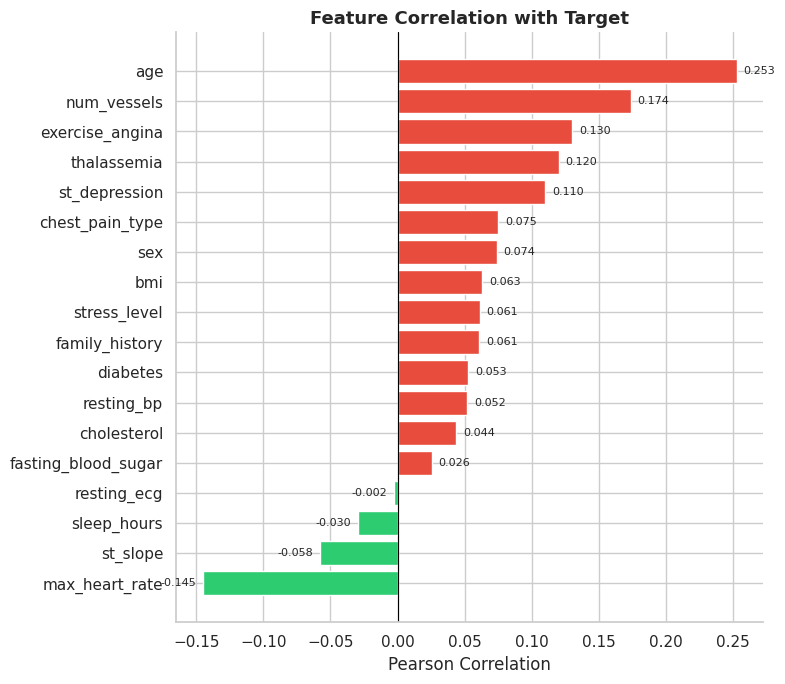

In [47]:
num_df = df.select_dtypes(include="number").drop(columns=["target"])

target_corr = df[num_df.columns].corrwith(df["target"]).sort_values()

colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in target_corr.values]

fig, ax = plt.subplots(figsize=(8, 7))

ax.barh(target_corr.index, target_corr.values, 
        color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)

# label each bar
for i, val in enumerate(target_corr.values):
    ax.text(
        val + (0.005 if val >= 0 else -0.005),
        i, f"{val:.3f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=8
    )

ax.set_title("Feature Correlation with Target", 
             fontweight="bold", fontsize=13)
ax.set_xlabel("Pearson Correlation")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [48]:
print("Before:", df.shape)

df = df.drop(columns=["patient_id"])

print("After:", df.shape)
print("\nColumns remaining:\n", df.columns.tolist())

Before: (10000, 23)
After: (10000, 22)

Columns remaining:
 ['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'st_depression', 'st_slope', 'num_vessels', 'thalassemia', 'bmi', 'smoking_status', 'diabetes', 'family_history', 'physical_activity', 'alcohol_consumption', 'stress_level', 'sleep_hours', 'target']


In [49]:
from sklearn.impute import SimpleImputer

cols_to_impute = ["cholesterol", "st_depression", "bmi", 
                  "stress_level", "sleep_hours"]

print("Missing values BEFORE imputation:")
print(df[cols_to_impute].isnull().sum())

# median imputation
imputer = SimpleImputer(strategy="median")
df[cols_to_impute] = imputer.fit_transform(df[cols_to_impute])

print("\nMissing values AFTER imputation:")
print(df[cols_to_impute].isnull().sum())

print("\nMedian values used for imputation:")
for col, median in zip(cols_to_impute, imputer.statistics_):
    print(f"  {col:<20} → {median}")

Missing values BEFORE imputation:
cholesterol      406
st_depression    211
bmi              183
stress_level     274
sleep_hours      294
dtype: int64

Missing values AFTER imputation:
cholesterol      0
st_depression    0
bmi              0
stress_level     0
sleep_hours      0
dtype: int64

Median values used for imputation:
  cholesterol          → 244.0
  st_depression        → 0.7
  bmi                  → 27.6
  stress_level         → 5.0
  sleep_hours          → 6.8


In [50]:
df.isnull().sum()

age                    0
sex                    0
chest_pain_type        0
resting_bp             0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
st_depression          0
st_slope               0
num_vessels            0
thalassemia            0
bmi                    0
smoking_status         0
diabetes               0
family_history         0
physical_activity      0
alcohol_consumption    0
stress_level           0
sleep_hours            0
target                 0
dtype: int64

In [51]:
cols_to_cap = ["cholesterol", "resting_bp", "st_depression", "bmi"]

print("Before capping:")
print(df[cols_to_cap].describe().round(2).loc[["min","max"]])

for col in cols_to_cap:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

print("\nAfter capping:")
print(df[cols_to_cap].describe().round(2).loc[["min","max"]])

Before capping:
     cholesterol  resting_bp  st_depression   bmi
min        120.0        85.0            0.0  15.0
max        468.0       198.0            6.5  47.9

After capping:
     cholesterol  resting_bp  st_depression   bmi
min       129.00        88.0            0.0  15.6
max       363.01       171.0            4.6  39.3


In [52]:
# --- Ordinal Encoding (order matters here) ---
# physical_activity: low < moderate < high (clear order)
# alcohol_consumption: none < light < heavy (clear order)

physical_activity_map = {"low": 0, "moderate": 1, "high": 2}
alcohol_map           = {"none": 0, "light": 1, "heavy": 2}

df["physical_activity"]   = df["physical_activity"].map(physical_activity_map)
df["alcohol_consumption"] = df["alcohol_consumption"].map(alcohol_map)

# --- One Hot Encoding (no natural order) ---
# smoking_status: never, former, current — no ranking between these
df = pd.get_dummies(df, columns=["smoking_status"], drop_first=True)

print("Shape after encoding:", df.shape)
print("\nNew columns added:")
print([col for col in df.columns if "smoking" in col])
print("\nphysical_activity sample:", df["physical_activity"].unique())
print("alcohol_consumption sample:", df["alcohol_consumption"].unique())

Shape after encoding: (10000, 23)

New columns added:
['smoking_status_former', 'smoking_status_never']

physical_activity sample: [1 0 2]
alcohol_consumption sample: [1 0 2]


In [53]:
df.shape

(10000, 23)

In [54]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducibility
    stratify=y            # preserve 60/40 ratio in both splits
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("\nTarget distribution in train:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTarget distribution in test:")
print(y_test.value_counts(normalize=True).round(3))

X_train shape: (8000, 22)
X_test shape : (2000, 22)

Target distribution in train:
target
1    0.603
0    0.397
Name: proportion, dtype: float64

Target distribution in test:
target
1    0.603
0    0.397
Name: proportion, dtype: float64


In [55]:
from sklearn.preprocessing import StandardScaler

# only scale these — not binary/ordinal columns
cols_to_scale = ["age", "resting_bp", "cholesterol", "max_heart_rate",
                 "st_depression", "bmi", "stress_level", "sleep_hours"]

scaler = StandardScaler()

# fit ONLY on train, transform both
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print("X_train sample after scaling:")
print(X_train[cols_to_scale].describe().round(3).loc[["mean", "std"]])

X_train sample after scaling:
      age  resting_bp  cholesterol  max_heart_rate  st_depression  bmi  \
mean  0.0         0.0         -0.0            -0.0            0.0  0.0   
std   1.0         1.0          1.0             1.0            1.0  1.0   

      stress_level  sleep_hours  
mean          -0.0         -0.0  
std            1.0          1.0  


In [56]:
print("Any nulls in X_train?", X_train.isnull().sum().sum())
print("Any nulls in X_test? ", X_test.isnull().sum().sum())
print("\nFinal shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Any nulls in X_train? 0
Any nulls in X_test?  0

Final shapes:
X_train: (8000, 22)
X_test : (2000, 22)
y_train: (8000,)
y_test : (2000,)


In [57]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    C=1.0,                    # regularization strength (lower = more regularization)
    solver="lbfgs",           # optimization algorithm, best for small-medium datasets
    max_iter=1000,            # give it enough iterations to converge
    class_weight="balanced",  # handles our 60/40 imbalance automatically
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully ✅")
print(f"\nNumber of features   : {model.n_features_in_}")
print(f"Number of iterations : {model.n_iter_[0]}")
print(f"Classes              : {model.classes_}")

Model trained successfully ✅

Number of features   : 22
Number of iterations : 23
Classes              : [0 1]


In [58]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    model, X_train, y_train,
    cv=cv,
    scoring=["accuracy", "f1", "roc_auc", "precision", "recall"],
    return_train_score=True
)

print("=" * 45)
print("CROSS VALIDATION RESULTS (5-Fold)")
print("=" * 45)

metrics = ["accuracy", "f1", "roc_auc", "precision", "recall"]

for metric in metrics:
    train_mean = scores[f"train_{metric}"].mean()
    test_mean  = scores[f"test_{metric}"].mean()
    test_std   = scores[f"test_{metric}"].std()
    print(f"\n{metric.upper():<12}")
    print(f"  Train : {train_mean:.4f}")
    print(f"  CV    : {test_mean:.4f} ± {test_std:.4f}")

CROSS VALIDATION RESULTS (5-Fold)

ACCURACY    
  Train : 0.6946
  CV    : 0.6915 ± 0.0023

F1          
  Train : 0.7310
  CV    : 0.7283 ± 0.0026

ROC_AUC     
  Train : 0.7612
  CV    : 0.7568 ± 0.0055

PRECISION   
  Train : 0.7794
  CV    : 0.7766 ± 0.0064

RECALL      
  Train : 0.6883
  CV    : 0.6857 ± 0.0078


In [59]:
# probability scores — not just 0/1
y_pred_proba = model.predict_proba(X_test)[:, 1]

# hard predictions using default 0.5 threshold
y_pred = model.predict(X_test)

print("Predicted probabilities (first 10):")
print(y_pred_proba[:10].round(3))

print("\nHard predictions (first 10):")
print(y_pred[:10])

print("\nActual values (first 10):")
print(y_test.values[:10])

Predicted probabilities (first 10):
[0.772 0.116 0.74  0.54  0.747 0.885 0.121 0.718 0.744 0.331]

Hard predictions (first 10):
[1 0 1 1 1 1 0 1 1 0]

Actual values (first 10):
[1 0 1 1 1 1 0 1 1 1]


In [60]:
from sklearn.metrics import (classification_report, accuracy_score,
                              f1_score, roc_auc_score)

print("=" * 45)
print("TEST SET EVALUATION")
print("=" * 45)

print(f"\nAccuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
                            target_names=["No Disease", "Disease"]))

TEST SET EVALUATION

Accuracy : 0.7165
F1 Score : 0.7523
ROC-AUC  : 0.7796

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.62      0.72      0.67       794
     Disease       0.80      0.71      0.75      1206

    accuracy                           0.72      2000
   macro avg       0.71      0.72      0.71      2000
weighted avg       0.73      0.72      0.72      2000



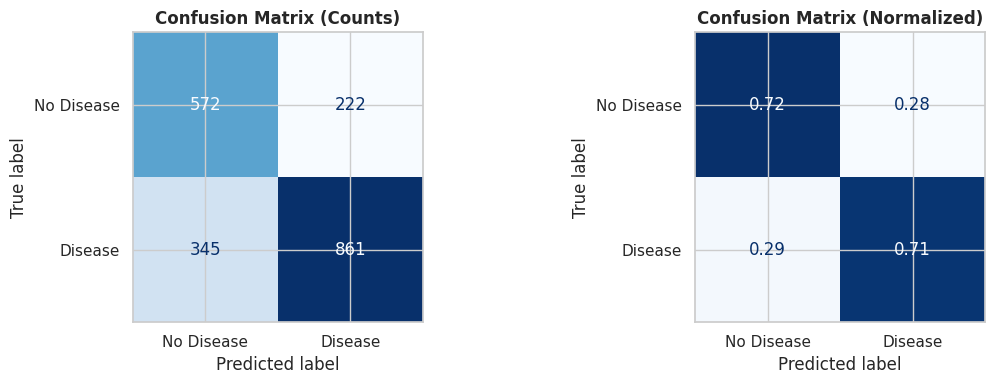


True  Negatives (Healthy   → Predicted Healthy)  : 572
False Positives (Healthy   → Predicted Disease)  : 222
False Negatives (Disease   → Predicted Healthy)  : 345  ← dangerous
True  Positives (Disease   → Predicted Disease)  : 861


In [61]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Plot 1: Raw counts ---
ConfusionMatrixDisplay(
    cm, 
    display_labels=["No Disease", "Disease"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix (Counts)", fontweight="bold")

# --- Plot 2: Normalized ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(
    cm_norm.round(2), 
    display_labels=["No Disease", "Disease"]
).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Confusion Matrix (Normalized)", fontweight="bold")

plt.tight_layout()
plt.show()

# print what each cell means
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue  Negatives (Healthy   → Predicted Healthy)  : {tn}")
print(f"False Positives (Healthy   → Predicted Disease)  : {fp}")
print(f"False Negatives (Disease   → Predicted Healthy)  : {fn}  ← dangerous")
print(f"True  Positives (Disease   → Predicted Disease)  : {tp}")


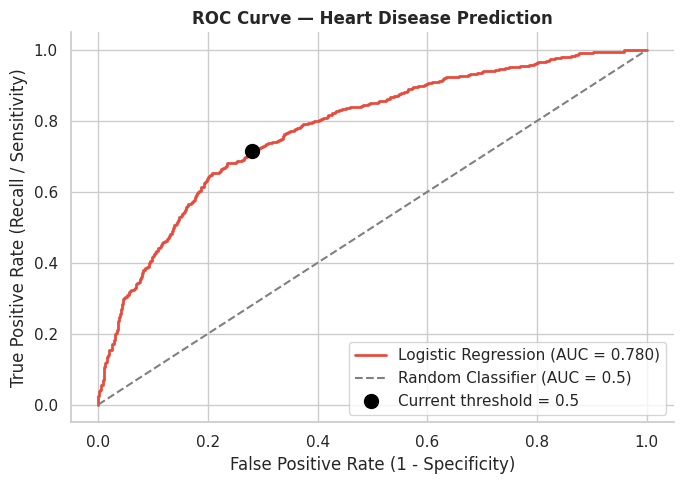

ROC-AUC : 0.7796

At threshold 0.5:
  FPR (False Alarm Rate) : 0.280
  TPR (Recall)           : 0.715


In [62]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))

# main ROC curve
ax.plot(fpr, tpr, color="#e74c3c", lw=2, 
        label=f"Logistic Regression (AUC = {roc_auc:.3f})")

# random classifier baseline
ax.plot([0, 1], [0, 1], color="gray", lw=1.5, 
        ls="--", label="Random Classifier (AUC = 0.5)")

# mark current operating point (threshold = 0.5)
current_idx = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(fpr[current_idx], tpr[current_idx],
           color="black", zorder=5, s=100,
           label=f"Current threshold = 0.5")

ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Recall / Sensitivity)")
ax.set_title("ROC Curve — Heart Disease Prediction", fontweight="bold")
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"\nAt threshold 0.5:")
print(f"  FPR (False Alarm Rate) : {fpr[current_idx]:.3f}")
print(f"  TPR (Recall)           : {tpr[current_idx]:.3f}")

In [63]:
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.01)

results = []
for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()
    tn = ((y_pred_t == 0) & (y_test == 0)).sum()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = (2 * precision * recall / (precision + recall) 
                 if (precision + recall) > 0 else 0)
    
    results.append({
        "threshold" : round(t, 2),
        "precision" : round(precision, 3),
        "recall"    : round(recall, 3),
        "f1"        : round(f1, 3)
    })

results_df = pd.DataFrame(results)

# find optimal thresholds
best_f1_row     = results_df.loc[results_df["f1"].idxmax()]
best_recall_row = results_df[results_df["recall"] >= 0.90].iloc[0]

print("Best threshold for F1:")
print(best_f1_row)
print("\nThreshold where recall first hits 90%:")
print(best_recall_row)


Best threshold for F1:
threshold    0.290
precision    0.685
recall       0.924
f1           0.787
Name: 19, dtype: float64

Threshold where recall first hits 90%:
threshold    0.100
precision    0.611
recall       1.000
f1           0.758
Name: 0, dtype: float64


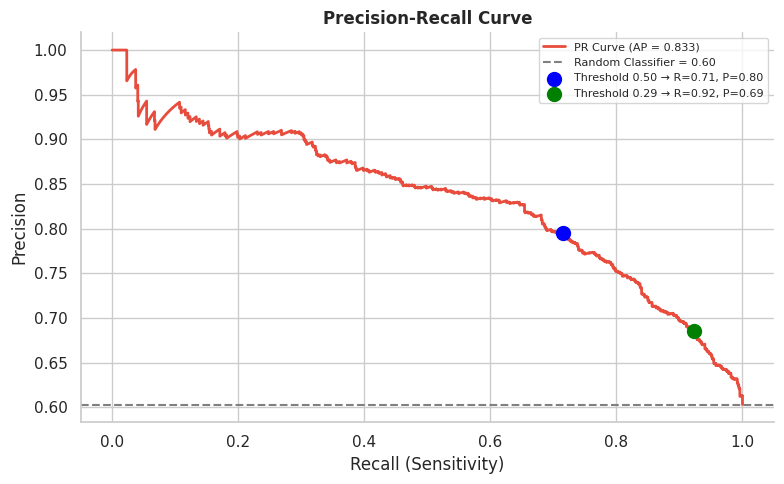

In [64]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, thresh_vals = precision_recall_curve(
    y_test, y_pred_proba
)
avg_precision = average_precision_score(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 5))

# main curve
ax.plot(recall_vals, precision_vals, 
        color="#e74c3c", lw=2,
        label=f"PR Curve (AP = {avg_precision:.3f})")

# baseline — random classifier
baseline = y_test.mean()
ax.axhline(baseline, color="gray", ls="--", lw=1.5,
           label=f"Random Classifier = {baseline:.2f}")

# mark default threshold 0.5
idx_05 = np.argmin(np.abs(thresh_vals - 0.50))
ax.scatter(recall_vals[idx_05], precision_vals[idx_05],
           color="blue", zorder=5, s=100,
           label=f"Threshold 0.50 → R={recall_vals[idx_05]:.2f}, P={precision_vals[idx_05]:.2f}")

# mark optimal threshold 0.29
idx_29 = np.argmin(np.abs(thresh_vals - 0.29))
ax.scatter(recall_vals[idx_29], precision_vals[idx_29],
           color="green", zorder=5, s=100,
           label=f"Threshold 0.29 → R={recall_vals[idx_29]:.2f}, P={precision_vals[idx_29]:.2f}")

ax.set_xlabel("Recall (Sensitivity)")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve", fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


In [65]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C"           : [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    "penalty"     : ["l1", "l2"],
    "solver"      : ["liblinear"],
    "class_weight": ["balanced"],
    "max_iter"    : [1000],
    "random_state": [42]
}

grid_search = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring="roc_auc",     # optimize for ROC-AUC
    n_jobs=-1,             # use all CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)
print(f"\nBest CV ROC-AUC : {grid_search.best_score_:.4f}")
print(f"Previous CV ROC-AUC : 0.7568")

Fitting 5 folds for each of 14 candidates, totalling 70 fits

Best Parameters:
{'C': 1.0, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2', 'random_state': 42, 'solver': 'liblinear'}

Best CV ROC-AUC : 0.7569
Previous CV ROC-AUC : 0.7568


Metric           Before      After     Change
ROC-AUC          0.7796     0.7794 ↓ 0.0001
F1               0.7516     0.7867 ↑ 0.0351
Recall           0.7139     0.9237 ↑ 0.2098
Precision        0.7935     0.6851 ↓ 0.1084

Classification Report (After Tuning):
              precision    recall  f1-score   support

  No Disease       0.75      0.36      0.48       794
     Disease       0.69      0.92      0.79      1206

    accuracy                           0.70      2000
   macro avg       0.72      0.64      0.63      2000
weighted avg       0.71      0.70      0.67      2000



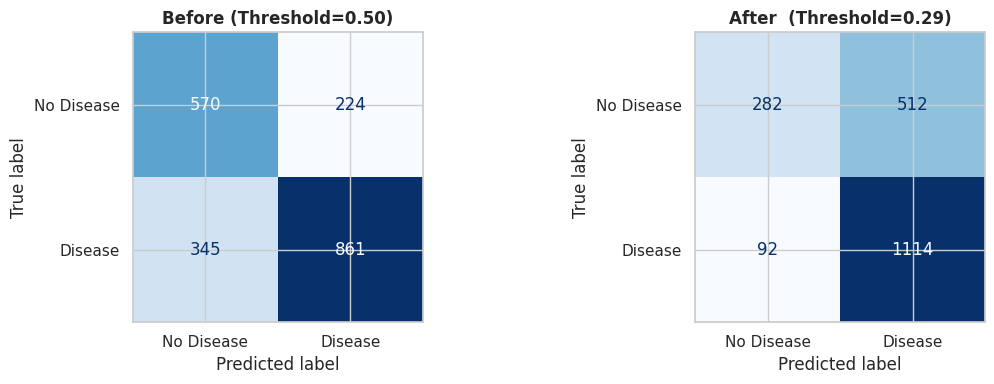

In [66]:
from sklearn.metrics import classification_report, confusion_matrix

# use best model from grid search
best_model = grid_search.best_estimator_

# get probabilities on test set
y_pred_proba_tuned = best_model.predict_proba(X_test)[:, 1]

# apply optimal threshold 0.29
y_pred_default = (y_pred_proba_tuned >= 0.50).astype(int)
y_pred_tuned   = (y_pred_proba_tuned >= 0.29).astype(int)

# --- Metrics comparison ---
from sklearn.metrics import (recall_score, precision_score, 
                              f1_score, roc_auc_score)

metrics = {
    "ROC-AUC"  : [roc_auc_score(y_test, y_pred_proba),
                  roc_auc_score(y_test, y_pred_proba_tuned)],
    "F1"       : [f1_score(y_test, y_pred_default),
                  f1_score(y_test, y_pred_tuned)],
    "Recall"   : [recall_score(y_test, y_pred_default),
                  recall_score(y_test, y_pred_tuned)],
    "Precision": [precision_score(y_test, y_pred_default),
                  precision_score(y_test, y_pred_tuned)],
}

print("=" * 50)
print(f"{'Metric':<12} {'Before':>10} {'After':>10} {'Change':>10}")
print("=" * 50)
for metric, (before, after) in metrics.items():
    change = after - before
    arrow  = "↑" if change > 0 else "↓"
    print(f"{metric:<12} {before:>10.4f} {after:>10.4f} "
          f"{arrow} {abs(change):.4f}")

print("\nClassification Report (After Tuning):")
print(classification_report(y_test, y_pred_tuned,
                            target_names=["No Disease", "Disease"]))

# confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in [
    (axes[0], y_pred_default, "Before (Threshold=0.50)"),
    (axes[1], y_pred_tuned,   "After  (Threshold=0.29)")
]:
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(
        cm, display_labels=["No Disease", "Disease"]
    ).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title, fontweight="bold")

plt.tight_layout()
plt.show()

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

# extract coefficients
coef_df = pd.DataFrame({
    "feature"    : X_train.columns,
    "coefficient": model.coef_[0]
})

# sort by absolute value — strongest features first
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)

print("=" * 45)
print("FEATURE COEFFICIENTS (sorted by strength)")
print("=" * 45)
print(coef_df[["feature", "coefficient"]].to_string(index=False))

FEATURE COEFFICIENTS (sorted by strength)
              feature  coefficient
      exercise_angina     0.675808
                  age     0.620798
          thalassemia     0.478145
          num_vessels     0.459762
                  sex     0.428902
       family_history     0.363637
             diabetes     0.349676
       max_heart_rate    -0.337323
        st_depression     0.271496
 smoking_status_never    -0.239764
             st_slope    -0.217096
    physical_activity    -0.196143
      chest_pain_type     0.179662
  fasting_blood_sugar     0.166569
                  bmi     0.158078
           resting_bp     0.155681
         stress_level     0.149717
          cholesterol     0.105599
smoking_status_former    -0.091349
  alcohol_consumption     0.086187
          sleep_hours    -0.068564
          resting_ecg    -0.028736


In [68]:
import numpy as np

coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])

# separate risk and protective features
risk_features       = coef_df[coef_df["odds_ratio"] > 1].copy()
protective_features = coef_df[coef_df["odds_ratio"] < 1].copy()

print("=" * 55)
print("ODDS RATIOS — Risk Features (OR > 1)")
print("=" * 55)
print(risk_features[["feature","coefficient","odds_ratio"]]
      .to_string(index=False))

print("\n" + "=" * 55)
print("ODDS RATIOS — Protective Features (OR < 1)")
print("=" * 55)
print(protective_features[["feature","coefficient","odds_ratio"]]
      .to_string(index=False))

ODDS RATIOS — Risk Features (OR > 1)
            feature  coefficient  odds_ratio
    exercise_angina     0.675808    1.965620
                age     0.620798    1.860412
        thalassemia     0.478145    1.613080
        num_vessels     0.459762    1.583697
                sex     0.428902    1.535571
     family_history     0.363637    1.438553
           diabetes     0.349676    1.418608
      st_depression     0.271496    1.311926
    chest_pain_type     0.179662    1.196813
fasting_blood_sugar     0.166569    1.181245
                bmi     0.158078    1.171258
         resting_bp     0.155681    1.168453
       stress_level     0.149717    1.161506
        cholesterol     0.105599    1.111376
alcohol_consumption     0.086187    1.090011

ODDS RATIOS — Protective Features (OR < 1)
              feature  coefficient  odds_ratio
       max_heart_rate    -0.337323    0.713678
 smoking_status_never    -0.239764    0.786814
             st_slope    -0.217096    0.804852
    physica

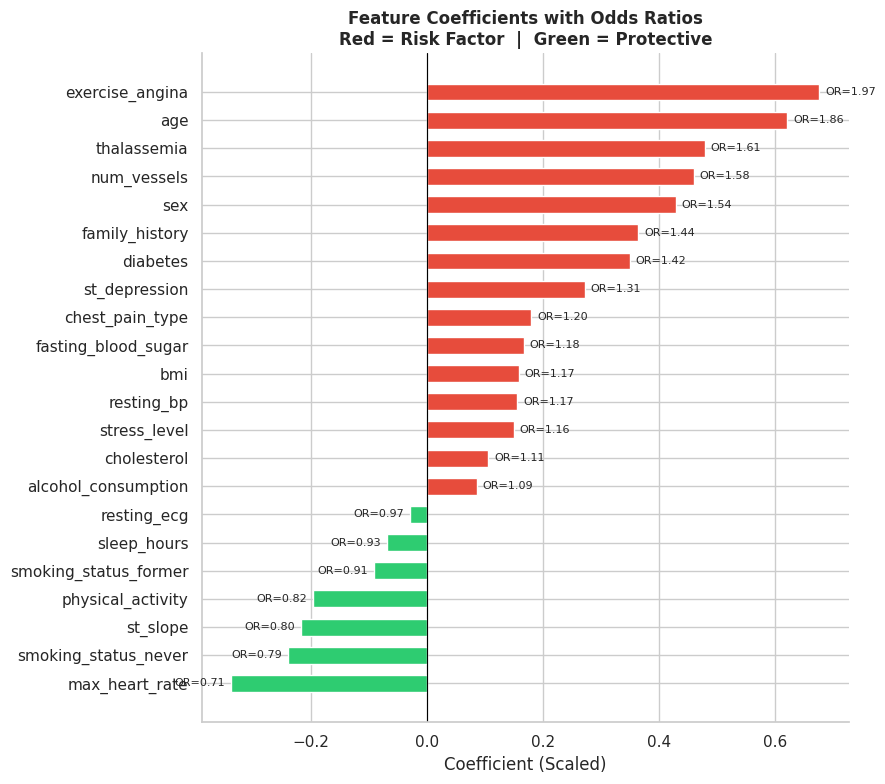

In [69]:
# rebuild sorted by coefficient value for clean viz
plot_df = coef_df.sort_values("coefficient", ascending=True)

colors = ["#e74c3c" if v > 0 else "#2ecc71" 
          for v in plot_df["coefficient"]]

fig, ax = plt.subplots(figsize=(9, 8))

bars = ax.barh(
    plot_df["feature"], 
    plot_df["coefficient"],
    color=colors, 
    edgecolor="white",
    height=0.6
)

# add odds ratio labels on each bar
for bar, (_, row) in zip(bars, plot_df.iterrows()):
    val  = row["coefficient"]
    oratio = row["odds_ratio"]
    ax.text(
        val + (0.01 if val >= 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f"OR={oratio:.2f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=8
    )

ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Coefficient (Scaled)")
ax.set_title("Feature Coefficients with Odds Ratios\nRed = Risk Factor  |  Green = Protective",
             fontweight="bold", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [70]:
!pip install shap -q
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [71]:
# use LinearExplainer for Logistic Regression
explainer   = shap.LinearExplainer(best_model, X_train)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)
print("X_test shape     :", X_test.shape)

SHAP values shape: (2000, 22)
X_test shape     : (2000, 22)


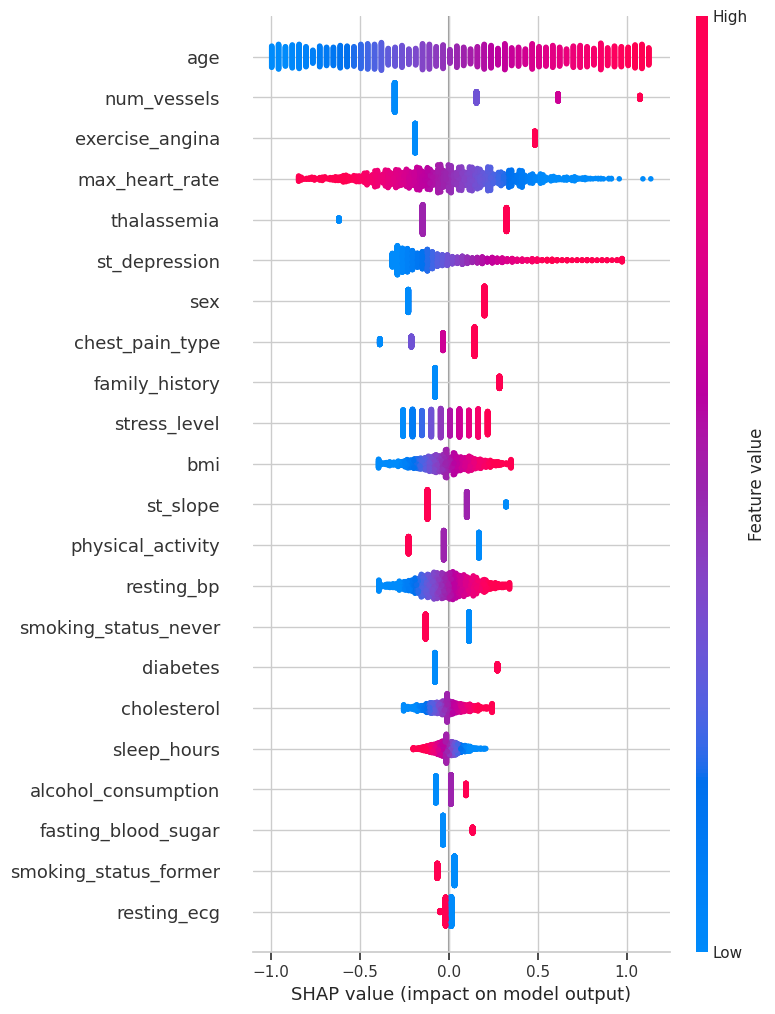

In [75]:
import numpy as np

# convert to numpy array — fixes the float/rint compatibility issue
X_test_array  = np.array(X_test, dtype=np.float64)
X_train_array = np.array(X_train, dtype=np.float64)

# refit explainer on numpy array
explainer   = shap.LinearExplainer(best_model, X_train_array)
shap_values = explainer.shap_values(X_test_array)

# now plot
shap.summary_plot(
    shap_values,
    X_test_array,
    feature_names=X_train.columns.tolist(),
    plot_type="dot",
    max_display=22,
    show=True
)